# Ashvini + pymctrees: live merger trees, delayed vs. instantaneous feedback

This notebook demonstrates the live pymctrees hook (`basics.tree_source: pymctrees`
in `run_params.yaml`, or directly via `ashvini.pymctrees_adapter.build_forest_live`):
generate a set of Monte Carlo merger trees, run Ashvini's baryonic model on them,
and compare stellar mass and gas mass growth under delayed vs. instantaneous
supernova feedback -- no intermediate HDF5 file needed.

Halo masses at z=5 span 1e7-1e8 Msun, sampled as three log-spaced bins
(1e7, 5e7, 1e8 -- matching the 1-5-10 per-decade convention the reference
tree file and `mass_bin_group_name` already use), each with its own set of
haloes. All Ashvini physics parameters (star formation efficiency, delay
time, reionization, dust, black holes, ...) are left at `run_params.yaml`'s
defaults throughout -- only the supernova feedback *type* is toggled
between the two comparison runs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ashvini import main, pymctrees_adapter
from ashvini.run_params import PARAMS

print(f"Default run_params.yaml: sf.efficiency={PARAMS.sf.efficiency}, "
      f"sn.delay_time={PARAMS.sn.delay_time} Gyr, sn.type={PARAMS.sn.type} (overridden below per run)")


Default run_params.yaml: sf.efficiency=0.015, sn.delay_time=0.015 Gyr, sn.type=delayed (overridden below per run)


## 1. Generate trees live via pymctrees

`build_forest_live` is exactly what `run()` calls internally when
`tree_source: pymctrees` is configured -- generating it directly here
(instead of going through `run()`/`run_params.yaml`) keeps this notebook
self-contained and lets us reuse the same trees for both feedback-type
comparisons below, rather than regenerating them per run.

`z_max=25`, `dz=0.01`, `M_res=100 Msun` matches the setup validated in the
earlier pymctrees-to-Ashvini validation work (deep enough to resolve
formation for these mass bins, fine enough to avoid the timestep-dependent
integration artifacts found there). `backend='numpy'` needs no JIT
warm-up, which is fine at this sample size (a few tens of haloes); switch
to `'numba'` for larger samples.


In [2]:
PYMCTREES_CONFIG = "/Users/00075868/MyCodes/pymctrees/config/planck2018_camb.yml"
MASS_BINS = [1e7, 5e7, 1e8]  # Msun, at z0
N_HALOS = 15
Z0, Z_MAX, DZ = 5.0, 25.0, 0.01
M_RES = 100.0  # Msun
SEED = 42

trees = {}  # mass_bin -> (halo_masses, halo_growth_rates, redshifts)
for mass_bin in MASS_BINS:
    halo_masses, halo_growth_rates, redshifts = pymctrees_adapter.build_forest_live(
        pymctrees_config_path=PYMCTREES_CONFIG, mass_bin=mass_bin,
        n_halos=N_HALOS, z0=Z0, z_max=Z_MAX, dz=DZ,
        m_res=M_RES, backend="numpy", seed=SEED,
    )
    trees[mass_bin] = (halo_masses, halo_growth_rates, redshifts)
    n_formed = int(np.sum(halo_masses[:, 0] > 0))
    print(f"M0={mass_bin:.0e} Msun: {halo_masses.shape[0]} haloes, "
          f"{halo_masses.shape[1]} steps, {n_formed}/{N_HALOS} resolved back to z={redshifts[0]:.1f}")


M0=1e+07 Msun: 15 haloes, 2001 steps, 0/15 resolved back to z=25.0


M0=5e+07 Msun: 15 haloes, 2001 steps, 0/15 resolved back to z=25.0


M0=1e+08 Msun: 15 haloes, 2001 steps, 0/15 resolved back to z=25.0


## 2. Run Ashvini: delayed vs. instantaneous feedback

`run_forest()` (the vectorised integrator `run()` also uses) reads its
supernova feedback type from the module-level `main.sn_type`, set once
from `run_params.yaml` at import time -- not re-read per call. Toggling
`main.sn_type` directly between calls (rather than editing
`run_params.yaml` and reimporting) is exactly the mechanism `run()` itself
relies on; it's not a workaround.


In [3]:
results = {}  # (mass_bin, sn_type) -> run_forest() output dict

for mass_bin, (halo_masses, halo_growth_rates, redshifts) in trees.items():
    for sn_type in ["delayed", "instantaneous"]:
        main.sn_type = sn_type
        results[(mass_bin, sn_type)] = main.run_forest(halo_masses, halo_growth_rates, redshifts)

# sanity check: every run produced finite, non-negative output
for key, result in results.items():
    for field in ["gas_mass", "stars_mass"]:
        arr = result[field]
        assert np.all(np.isfinite(arr)) and np.all(arr >= 0), f"{key} {field} failed sanity check"
print(f"Ran {len(results)} (mass_bin, sn_type) combinations, all finite and non-negative.")


Ran 6 (mass_bin, sn_type) combinations, all finite and non-negative.


## 3. Stellar mass vs. cosmic time

Individual halo trajectories overlaid (not medians), so the real
halo-to-halo and merger-driven scatter within a mass bin is visible --
matching the diagnostic style used to originally isolate the genuine
delayed-feedback oscillation from tree-driven accretion-spike noise.


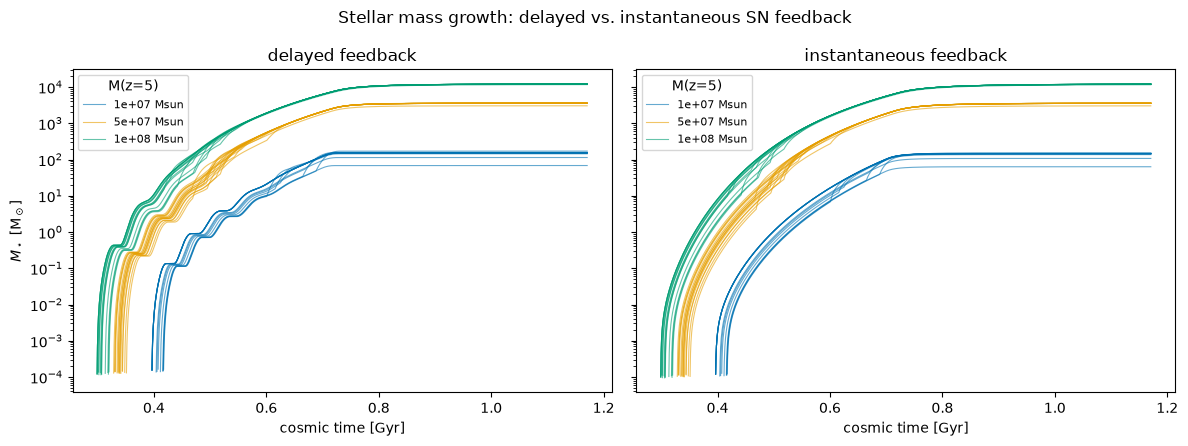

In [4]:
colors = {1e7: "#0072B2", 5e7: "#E69F00", 1e8: "#009E73"}  # Okabe-Ito

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, sharex=True)
for ax, sn_type in zip(axes, ["delayed", "instantaneous"]):
    for mass_bin in MASS_BINS:
        result = results[(mass_bin, sn_type)]
        t = result["cosmic_time"]
        stars = result["stars_mass"]
        for i in range(stars.shape[0]):
            row = stars[i]
            nz = np.where(row > 0)[0]
            if len(nz) == 0:
                continue
            label = f"{mass_bin:.0e} Msun" if i == 0 else None
            ax.plot(t[nz], row[nz], color=colors[mass_bin], lw=0.8, alpha=0.6, label=label)
    ax.set_yscale("log")
    ax.set_xlabel("cosmic time [Gyr]")
    ax.set_title(f"{sn_type} feedback")
    ax.legend(fontsize=8, title="M(z=5)")
axes[0].set_ylabel(r"$M_\star$ [M$_\odot$]")
fig.suptitle("Stellar mass growth: delayed vs. instantaneous SN feedback")
plt.tight_layout()
plt.savefig("stellar_mass_delayed_vs_instantaneous.png", dpi=130)
plt.show()


## 4. Gas mass vs. cosmic time

Same layout. This is where the delayed-feedback self-regulation
oscillation (a dip-and-recovery in gas mass, absent under instantaneous
feedback for the same halo/accretion history) is easiest to see, though it
can be masked by real merger-driven accretion spikes for any individual
noisy halo -- see the earlier validation work for how to isolate a
smooth-accreting halo specifically if you want to confirm the effect
cleanly rather than just eyeball it here.


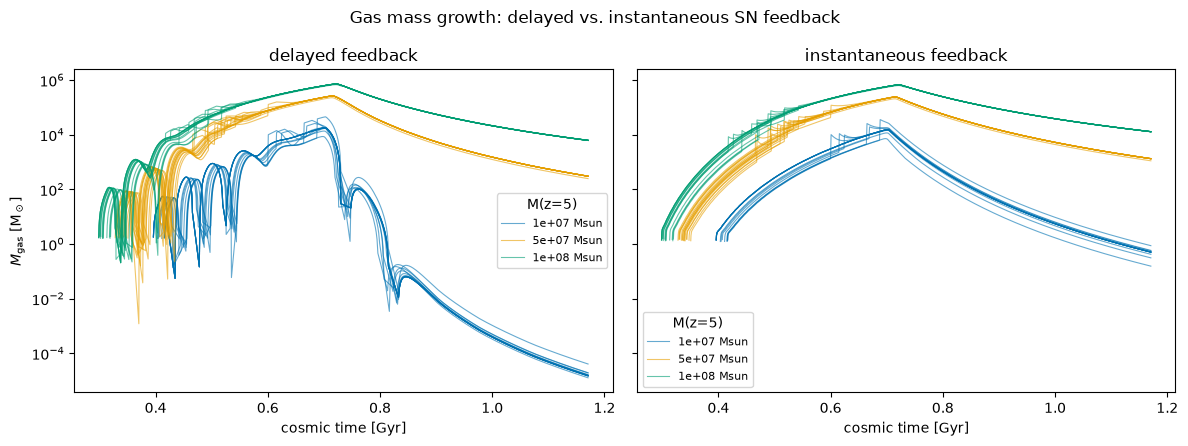

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, sharex=True)
for ax, sn_type in zip(axes, ["delayed", "instantaneous"]):
    for mass_bin in MASS_BINS:
        result = results[(mass_bin, sn_type)]
        t = result["cosmic_time"]
        gas = result["gas_mass"]
        for i in range(gas.shape[0]):
            row = gas[i]
            nz = np.where(row > 0)[0]
            if len(nz) == 0:
                continue
            label = f"{mass_bin:.0e} Msun" if i == 0 else None
            ax.plot(t[nz], row[nz], color=colors[mass_bin], lw=0.8, alpha=0.6, label=label)
    ax.set_yscale("log")
    ax.set_xlabel("cosmic time [Gyr]")
    ax.set_title(f"{sn_type} feedback")
    ax.legend(fontsize=8, title="M(z=5)")
axes[0].set_ylabel(r"$M_{\rm gas}$ [M$_\odot$]")
fig.suptitle("Gas mass growth: delayed vs. instantaneous SN feedback")
plt.tight_layout()
plt.savefig("gas_mass_delayed_vs_instantaneous.png", dpi=130)
plt.show()


## Next steps

- Swap `PYMCTREES_CONFIG` for a WDM/FDM/sharp-k pymctrees config
  (see pymctrees' own `config/*.yml` examples) to compare baryonic growth
  across dark matter models -- the live hook needs no changes for that,
  same as pymctrees' own tree-building code doesn't.
- Increase `N_HALOS` and switch `backend` to `'numba'` for a larger,
  more statistically robust sample.
- To reuse a generated forest across many `run_params.yaml` sweeps
  without regenerating it each time, build one offline instead with
  `scripts/build_trees_from_pymctrees.py` and point `tree_file`/
  `tree_source: file` at it.
